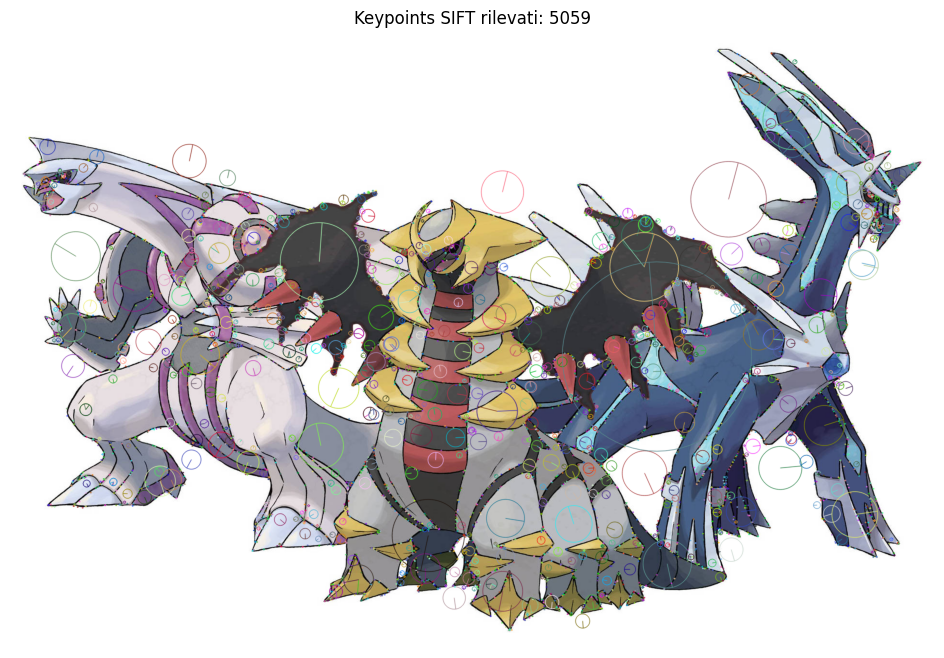

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Caricamento immagine
img_bgr = cv2.imread('../images/mosketeers.jpg')
if img_bgr is None:
    # Fallback se non trova il file
    img_bgr = np.zeros((400, 400, 3), dtype=np.uint8)
    cv2.circle(img_bgr, (200, 200), 100, (255, 255, 255), -1)
    cv2.line(img_bgr, (0,0), (400, 400), (255, 255, 255), 5)

gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# 2. Inizializziamo SIFT
# SIFT ha un parametro 'edgeThreshold' che controlla quanto è severo nel filtrare i bordi
sift = cv2.SIFT_create(edgeThreshold=10) 

# 3. Rilevamento dei Keypoints
keypoints = sift.detect(gray, None)

# 4. Visualizzazione
# flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS disegna il cerchio con orientamento
img_sift = cv2.drawKeypoints(img_bgr, keypoints, None, 
                             flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB))
plt.title(f"Keypoints SIFT rilevati: {len(keypoints)}")
plt.axis('off')
plt.show()

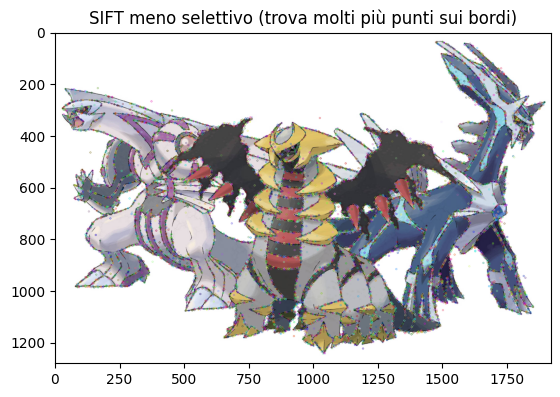

In [ ]:
# Aumenta edgeThreshold: il detector diventa "meno schizzinoso" sui bordi
sift_loose = cv2.SIFT_create(edgeThreshold=100) 
kp_loose = sift_loose.detect(gray, None)
img_loose = cv2.drawKeypoints(img_bgr, kp_loose, None)

plt.imshow(cv2.cvtColor(img_loose, cv2.COLOR_BGR2RGB))
plt.title("SIFT meno selettivo (trova molti più punti sui bordi)")
plt.show()

La direzione dominante del punto è: 220 gradi


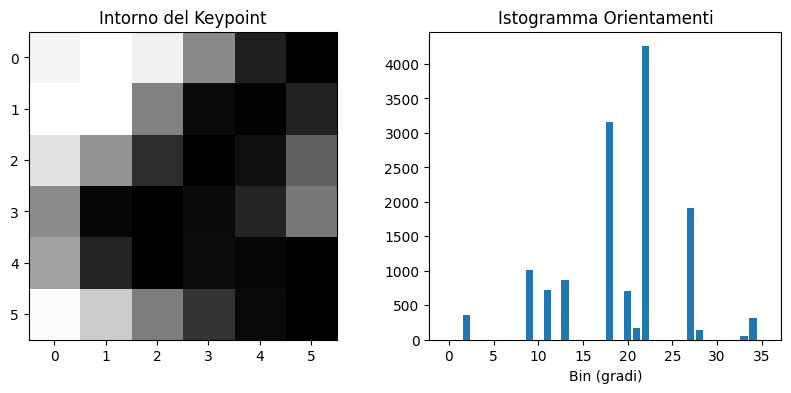

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Carica e Ruota
img = cv2.imread('../images/mosketeers.jpg', cv2.IMREAD_GRAYSCALE)
rows, cols = img.shape
M = cv2.getRotationMatrix2D((cols/2, rows/2), 45, 1)
img_rot = cv2.warpAffine(img, M, (cols, rows))

# 2. Rileviamo punti su entrambe (usiamo SIFT che è robusto)
sift = cv2.SIFT_create()
kp1 = sift.detect(img, None)
kp2 = sift.detect(img_rot, None)

# Per semplicità, prendiamo il keypoint più forte in entrambe le immagini
# Nota: in un caso reale useresti il matching per trovare il punto corrispondente
p1 = kp1[0] 
p2 = kp2[0] # Assumiamo per brevità che sia il corrispondente

def get_hog_hist(image, kp):
    x, y = int(kp.pt[0]), int(kp.pt[1])
    size = max(int(kp.size), 10) # Limita la dimensione
    
    # Estrai e ridimensiona per sicurezza
    y1, y2 = max(0, y-size), min(image.shape[0], y+size)
    x1, x2 = max(0, x-size), min(image.shape[1], x+size)
    patch = image[y1:y2, x1:x2]
    patch = cv2.resize(patch, (32, 32)) # Forza una dimensione fissa per velocità
    
    gx = cv2.Sobel(patch, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(patch, cv2.CV_32F, 0, 1, ksize=3)
    mag, ang = cv2.cartToPolar(gx, gy, angleInDegrees=True)
    
    # Usiamo np.histogram per evitare i cicli for lenti
    hist, _ = np.histogram(ang, bins=36, range=(0, 360), weights=mag)
    return hist

h1 = get_hog_hist(img, p1)
h2 = get_hog_hist(img_rot, p2)

# 3. Confronto
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1); plt.bar(range(36), h1); plt.title("Istogramma Originale")
plt.subplot(1,2,2); plt.bar(range(36), h2); plt.title("Istogramma Ruotato (Traslato)")
plt.show()